In [79]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from statsmodels.stats.power import TTestPower

In [80]:
# import datasets
df = pd.read_csv("../dataset/global_gdp_inflation_2000_2024.csv")
df

,Year,Country,ISO3,GDP_Growth_Percent,Inflation_Percent,Data_Type,Source
0,2001,Afghanistan,AFG,-9.431974,NaN,Historical,World Bank API
1,2002,Afghanistan,AFG,28.600001,NaN,Historical,World Bank API
2,2003,Afghanistan,AFG,8.832278,NaN,Historical,World Bank API
3,2004,Afghanistan,AFG,1.414118,NaN,Historical,World Bank API
4,2005,Afghanistan,AFG,11.229715,12.686269,Historical,World Bank API
...,...,...,...,...,...,...,...
5199,2020,Zimbabwe,ZWE,-7.816951,557.201817,Historical,World Bank API
5200,2021,Zimbabwe,ZWE,8.468017,98.546105,Historical,World Bank API
5201,2022,Zimbabwe,ZWE,6.139263,104.705171,Historical,World Bank API
5202,2023,Zimbabwe,ZWE,5.350869,NaN,Historical,World Bank API


In [81]:
# creating new data for philippines and indonesia gdp growth
df = df[df["Country"].isin(["Philippines", "Indonesia"])]
df = df.pivot(index="Year", columns="Country", values="GDP_Growth_Percent").reset_index()
df = df.sort_values("Year").reset_index(drop=True)
df

Country,Year,Indonesia,Philippines
0,2000,4.920068,4.382505
1,2001,3.643466,3.049231
2,2002,4.499475,3.716255
3,2003,4.780369,5.086911
4,2004,5.030874,6.569229
5,2005,5.692571,4.942505
6,2006,5.500952,5.316417
7,2007,6.345022,6.519292
8,2008,6.013704,4.344487
9,2009,4.628871,1.448323


In [82]:
# create .csv file for the new data
df.to_csv("../dataset/philippines_indonesia_gdp_growth.csv", index=False)

In [83]:
# open the new .csv file
df = pd.read_csv("../dataset/philippines_indonesia_gdp_growth.csv", delimiter=",")
df.set_index('Year', inplace=True)
print(df)

      Indonesia  Philippines
Year                        
2000   4.920068     4.382505
2001   3.643466     3.049231
2002   4.499475     3.716255
2003   4.780369     5.086911
2004   5.030874     6.569229
2005   5.692571     4.942505
2006   5.500952     5.316417
2007   6.345022     6.519292
2008   6.013704     4.344487
2009   4.628871     1.448323
2010   6.223854     7.334500
2011   6.169784     3.858233
2012   6.030051     6.896952
2013   5.557264     6.750531
2014   5.006668     6.347987
2015   4.876322     6.348310
2016   5.033069     7.149457
2017   5.069786     6.930988
2018   5.174292     6.341486
2019   5.019288     6.118526
2020  -2.065512    -9.518295
2021   3.702886     5.714733
2022   5.307197     7.580982
2023   5.049023     5.518950
2024   5.030345     5.692016


In [84]:
# summary of 2 selected countries
df.describe()

,Indonesia,Philippines
count,25.000000,25.000000
mean,4.889588,4.977620
std,1.601276,3.359690
min,-2.065512,-9.518295
25%,4.876322,4.382505
50%,5.033069,5.714733
75%,5.557264,6.569229
max,6.345022,7.580982


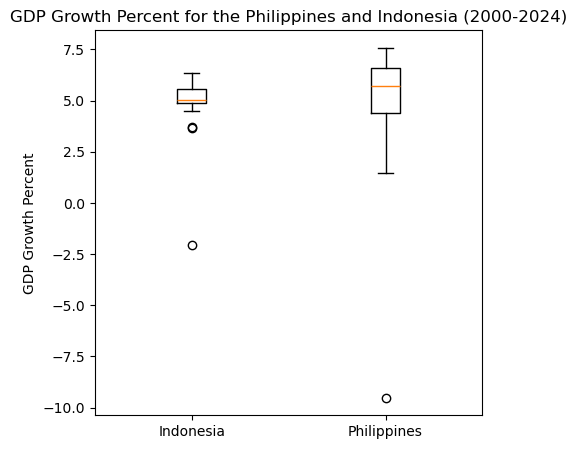

In [85]:
# check for outliers
plt.figure(figsize=(5,5))
plt.boxplot(df[['Indonesia','Philippines']],
            tick_labels=df.columns)
plt.title('GDP Growth Percent for the Philippines and Indonesia (2000-2024)')
plt.ylabel('GDP Growth Percent')
#plt.xticks(rotation=45)
plt.show()

In [86]:
# removing 3-sigma outliers
z_nuclear = stats.zscore(df['Indonesia'])
nuc_outliers = (z_nuclear<-3)|(z_nuclear>3)
df = df[~nuc_outliers]

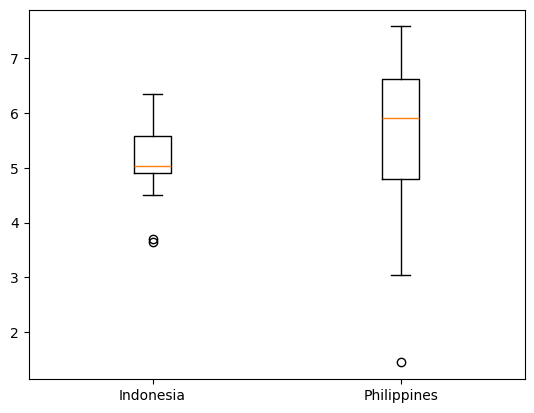

In [87]:
# wind
# removing 3-sigma outliers
z_wind = stats.zscore(df['Philippines'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]
plt.boxplot(df[['Indonesia','Philippines']],tick_labels=df.columns)
plt.show()

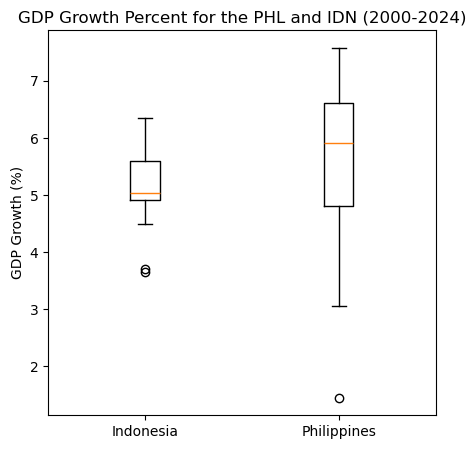

In [88]:
# check for outliers
plt.figure(figsize=(5,5))
plt.boxplot(df[['Indonesia','Philippines']],tick_labels=['Indonesia','Philippines'])
plt.title("GDP Growth Percent for the PHL and IDN (2000-2024)")
plt.ylabel('GDP Growth (%)')
plt.show()

# Indonesia Vs Philippines

In [89]:
# shapiro-wilk normality test
IDNw_stat, IDNp_value = stats.shapiro(df['Indonesia'])
print("Indonesia:")
print(f"w_stat: {IDNw_stat:.4f}")
print(f"P-value: {IDNp_value:.4f}")

# verdict
alpha = 0.05
if IDNp_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data \n")

# shapiro-wilk normality test
PHLw_stat, PHLp_value = stats.shapiro(df['Philippines'])

print("Philippines:")
print(f"w_stat: {PHLw_stat:.4f}")
print(f"P-value: {PHLp_value:.4f}")

# verdict
alpha = 0.05
if PHLp_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Indonesia:
w_stat: 0.9359
P-value: 0.1322
Normal data 

Philippines:
w_stat: 0.9241
P-value: 0.0719
Normal data


In [90]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_nuclear = var_coal
Ha: var_nuclear != var_coal
"""

var_nuc = df['Indonesia'].var(ddof=1)
var_coal = df['Philippines'].var(ddof=1)

# F-statistic
if var_nuc > var_coal:
    f_stat = var_nuc/var_coal
else:
    f_stat = var_coal/var_nuc

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_nuc = df['Indonesia'].count()-1
dof_coal = df['Philippines'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_nuc, dof_coal)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 4.6653
p_value = 0.0002
unequal variances


In [91]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Indonesia <= Philippines
Ha: Indonesia > Philippines
"""

t_stat, p_value = stats.ttest_ind(df['Indonesia'],df['Philippines'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("IDN-type is better than PHL-type.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between IDN-type and PHL-type.")

t_stat = -1.1891
p_value = 0.8797
There is no significant difference between IDN-type and PHL-type.


In [93]:
from statsmodels.stats.power import TTestIndPower

# 1. Calculate Pooled Standard Deviation
n_phl = df['Philippines'].count()
n_idn = df['Indonesia'].count()
std_phl = df['Philippines'].std(ddof=1)
std_idn = df['Indonesia'].std(ddof=1)

# The pooled variance formula
pooled_std = np.sqrt(((n_phl - 1)*std_phl**2 + (n_idn - 1)*std_idn**2) / (n_phl + n_idn - 2))

# 2. Calculate true Cohen's d (Philippines - Indonesia)
# Notice we don't use abs() here. 
# If PHL is smaller than IDN, this will naturally be a negative number.
phl_mean = df['Philippines'].mean()
idn_mean = df['Indonesia'].mean()
cohens_d = (phl_mean - idn_mean) / pooled_std

print(f"Cohen's d: {abs(cohens_d):.4f}")

# 3. Calculate Independent Power
power = TTestIndPower().power(
    effect_size = cohens_d,       # Naturally negative if PHL < IDN
    nobs1 = n_phl,                # The number of observations in group 1
    ratio = n_idn / n_phl,        # The ratio of sample sizes (usually 1.0)
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Correct Power of the test: {power*100:.2f}%")

Cohen's d: 0.3433
Correct Power of the test: 0.24%
